# Part 2: Vehicle Detection — YOLOv8 Training

**Classes:** bus, car, motorcycle, truck  
**Dataset:** 874 images (train: 714, val: 80, test: 80)  
**Model:** YOLOv8n (nano)

## Why YOLOv8?
- State-of-the-art real-time object detection (2023)
- Anchor-free architecture — better accuracy on small objects
- Simple Python API via `ultralytics` library
- Multiple model sizes: nano → extra-large (we use nano for speed)
- Built-in support for YOLO label format — no conversion needed

## Step 1: Connect Google Drive and Check GPU

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Check GPU availability
!nvidia-smi

Tue Apr 21 10:26:00 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Step 2: Install Dependencies

In [3]:
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 30.7 MB/s eta 0:00:00


In [4]:
import ultralytics
ultralytics.checks()

Ultralytics 8.4.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 42.9/112.6 GB disk)


## Step 3: Upload Dataset to Google Drive

Before running this step, upload the dataset folder to Google Drive manually:

```
MyDrive/
└── vehicle-detection-project/
    ├── train/
    │   ├── images/
    │   └── labels/
    ├── val/
    │   ├── images/
    │   └── labels/
    ├── test/
    │   ├── images/
    │   └── labels/
    └── data.yaml
```

In [5]:
import os

DATASET_PATH = '/content/drive/MyDrive/vehicle_detection/vehicle-detection-project'
DATA_YAML    = os.path.join(DATASET_PATH, 'data.yaml')

# Verify structure
for split in ['train', 'val', 'test']:
    imgs = os.path.join(DATASET_PATH, split, 'images')
    lbls = os.path.join(DATASET_PATH, split, 'labels')
    n_imgs = len(os.listdir(imgs)) if os.path.exists(imgs) else 0
    n_lbls = len(os.listdir(lbls)) if os.path.exists(lbls) else 0
    print(f'{split}: {n_imgs} images, {n_lbls} labels')

train: 714 images, 714 labels
val: 80 images, 80 labels
test: 80 images, 80 labels


## Step 4: Fix data.yaml Paths for Colab

In [6]:
import yaml

with open(DATA_YAML, 'r') as f:
    config = yaml.safe_load(f)

# Update path to absolute Colab path
config['path'] = DATASET_PATH

COLAB_YAML = '/content/data.yaml'
with open(COLAB_YAML, 'w') as f:
    yaml.dump(config, f)

print('data.yaml updated:')
print(yaml.dump(config))

data.yaml updated:
names:
  0: bus
  1: car
  2: motorcycle
  3: truck
path: /content/drive/MyDrive/vehicle_detection/vehicle-detection-project
test: test/images
train: train/images
val: val/images



## Step 5: Train YOLOv8

In [7]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')  # Load pretrained YOLOv8 nano

results = model.train(
    data=COLAB_YAML,
    epochs=50,
    batch=16,
    imgsz=640,
    patience=10,        # Early stopping if no improvement for 10 epochs
    device=0,           # GPU
    project='/content/drive/MyDrive/vehicle_detection/vehicle-detection-project/runs',
    name='yolov8n_vehicle',
    exist_ok=True
)

Ultralytics 8.4.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_vehicle, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10, persp

## Step 6: Plot Training Results

Columns found: ['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']
mAP50 column: metrics/mAP50(B)
mAP50-95 column: metrics/mAP50-95(B)


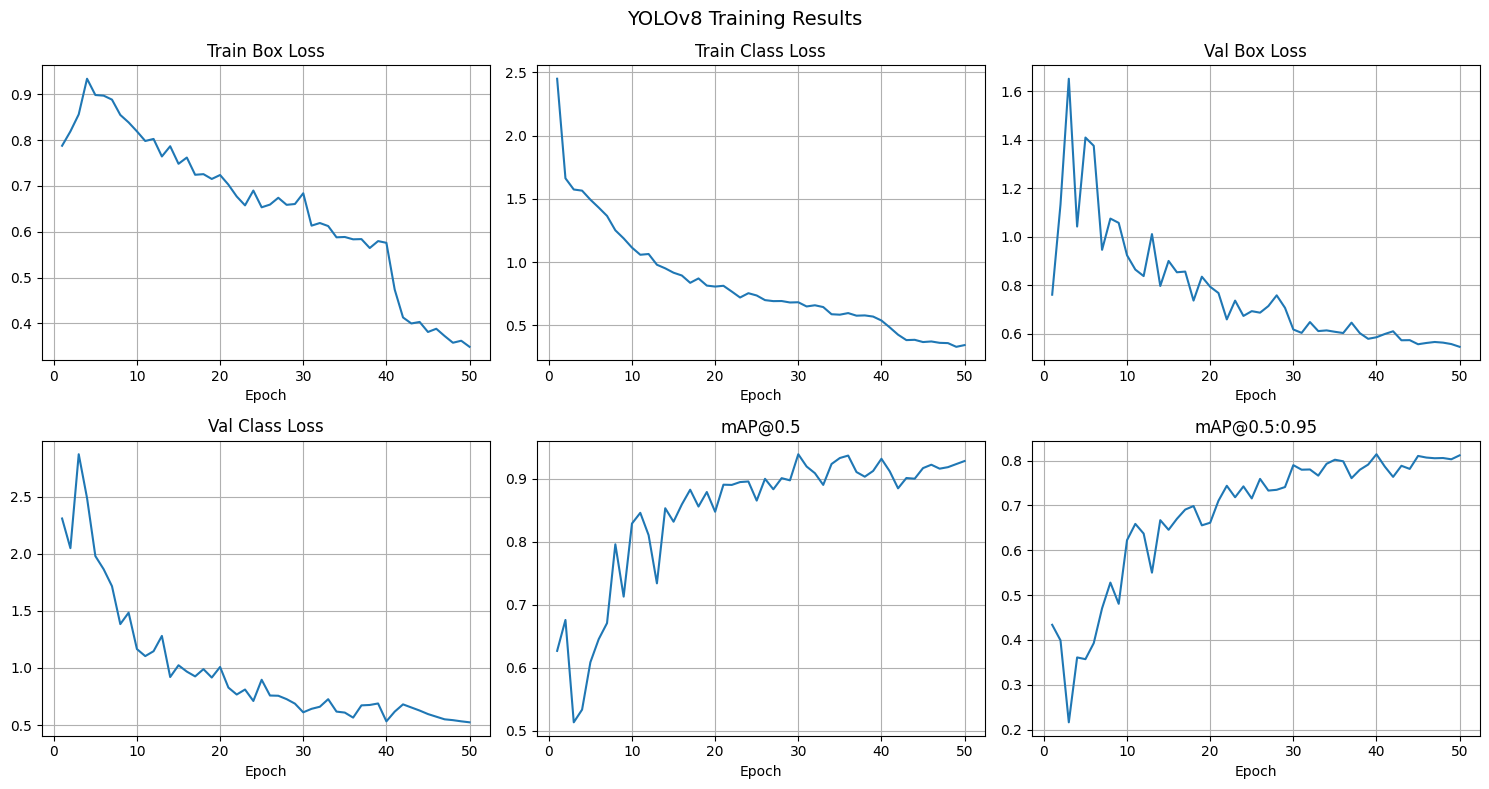

Graph saved.


In [11]:
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_CSV = '/content/drive/MyDrive/vehicle_detection/vehicle-detection-project/runs/yolov8n_vehicle/results.csv'
df = pd.read_csv(RESULTS_CSV)
df.columns = df.columns.str.strip()

# Auto-detect mAP column names (differ between ultralytics versions)
map50_col    = next((c for c in df.columns if 'mAP50' in c and '95' not in c), None)
map5095_col  = next((c for c in df.columns if 'mAP50-95' in c), None)

print("Columns found:", list(df.columns))
print(f"mAP50 column: {map50_col}")
print(f"mAP50-95 column: {map5095_col}")

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('YOLOv8 Training Results', fontsize=14)

plots = [
    ('train/box_loss',  'Train Box Loss',   axes[0, 0]),
    ('train/cls_loss',  'Train Class Loss', axes[0, 1]),
    ('val/box_loss',    'Val Box Loss',     axes[0, 2]),
    ('val/cls_loss',    'Val Class Loss',   axes[1, 0]),
    (map50_col,         'mAP@0.5',          axes[1, 1]),
    (map5095_col,       'mAP@0.5:0.95',    axes[1, 2]),
]

for col, title, ax in plots:
    if col and col in df.columns:
        ax.plot(df['epoch'], df[col])
        ax.set_title(title)
        ax.set_xlabel('Epoch')
        ax.grid(True)
    else:
        ax.set_title(f'{title} (not found)')
        ax.axis('off')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/vehicle_detection/vehicle-detection-project/runs/training_results.png', dpi=150)
plt.show()
print('Graph saved.')

## Step 7: Evaluate on Validation Set

In [10]:
WEIGHTS = '/content/drive/MyDrive/vehicle_detection/vehicle-detection-project/runs/yolov8n_vehicle/weights/best.pt'
model_best = YOLO(WEIGHTS)

val_results = model_best.val(data=COLAB_YAML, split='val')

print(f"mAP@0.5:      {val_results.box.map50:.4f}")
print(f"mAP@0.5:0.95: {val_results.box.map:.4f}")
print(f"Precision:    {val_results.box.mp:.4f}")
print(f"Recall:       {val_results.box.mr:.4f}")

Ultralytics 8.4.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.6±0.2 ms, read: 24.6±8.3 MB/s, size: 42.8 KB)
val: Scanning /content/drive/MyDrive/vehicle_detection/vehicle-detection-project/val/labels.cache... 80 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 80/80 28.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.0it/s 4.9s
                   all         80         97      0.945      0.855      0.932      0.814
                   bus         18         20      0.979       0.85      0.932      0.869
                   car         25         31      0.959      0.756      0.933      0.855
            motorcycle         26         29      0.986      0.931      0.989      0.802
                 truck         17         17      0.856      0.882      0.874      0.729
Speed: 13.

## Step 8: Evaluate on Test Set

In [12]:
test_results = model_best.val(data=COLAB_YAML, split='test')

print(f"Test mAP@0.5:      {test_results.box.map50:.4f}")
print(f"Test mAP@0.5:0.95: {test_results.box.map:.4f}")
print(f"Test Precision:    {test_results.box.mp:.4f}")
print(f"Test Recall:       {test_results.box.mr:.4f}")

Ultralytics 8.4.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.6±0.2 ms, read: 0.1±0.0 MB/s, size: 51.4 KB)
val: Scanning /content/drive/MyDrive/vehicle_detection/vehicle-detection-project/test/labels... 80 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 80/80 1.1it/s 1:11
val: New cache created: /content/drive/MyDrive/vehicle_detection/vehicle-detection-project/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.3it/s 3.9s
                   all         80         96      0.963      0.898      0.932      0.792
                   bus         23         28      0.992      0.893      0.895      0.811
                   car         21         28      0.878      0.714      0.842      0.746
            motorcycle         15         15      0.984          1      0.995      0.728
                 truck         24         25          1      0.985      0.995 

## Step 9: Generate Prediction Outputs with Bounding Boxes

In [13]:
import glob
from IPython.display import display, Image as IPImage

TEST_IMAGES = os.path.join(DATASET_PATH, 'test', 'images')
PRED_OUTPUT = '/content/drive/MyDrive/vehicle_detection/vehicle-detection-project/runs/predictions'

# Run predictions on test images
model_best.predict(
    source=TEST_IMAGES,
    save=True,
    project=PRED_OUTPUT,
    name='test_predictions',
    conf=0.25,
    exist_ok=True
)

print('Predictions saved to:', PRED_OUTPUT)


image 1/80 /content/drive/MyDrive/vehicle_detection/vehicle-detection-project/test/images/bus_104_jpg.rf.9e59f1c2a1c4681e72fdcad4a754fed1.jpg: 640x640 1 bus, 1 car, 7.2ms
image 2/80 /content/drive/MyDrive/vehicle_detection/vehicle-detection-project/test/images/bus_105_jpg.rf.03e1cbe5efb72eeed149933ad8515f57.jpg: 640x640 1 bus, 7.2ms
image 3/80 /content/drive/MyDrive/vehicle_detection/vehicle-detection-project/test/images/bus_106_jpg.rf.ac6cf823d18b7db871f434aa734af1a3.jpg: 640x640 2 buss, 7.2ms
image 4/80 /content/drive/MyDrive/vehicle_detection/vehicle-detection-project/test/images/bus_124_jpg.rf.c3450e257ba9d9644d8243d2f8a23705.jpg: 640x640 1 bus, 7.2ms
image 5/80 /content/drive/MyDrive/vehicle_detection/vehicle-detection-project/test/images/bus_130_jpg.rf.9dd93304025c628f7ddfe6388e35e50c.jpg: 640x640 1 bus, 2 cars, 7.2ms
image 6/80 /content/drive/MyDrive/vehicle_detection/vehicle-detection-project/test/images/bus_149_jpg.rf.9b4a816095e1edc4ce3ca6a210f17017.jpg: 640x640 1 bus, 7.2ms

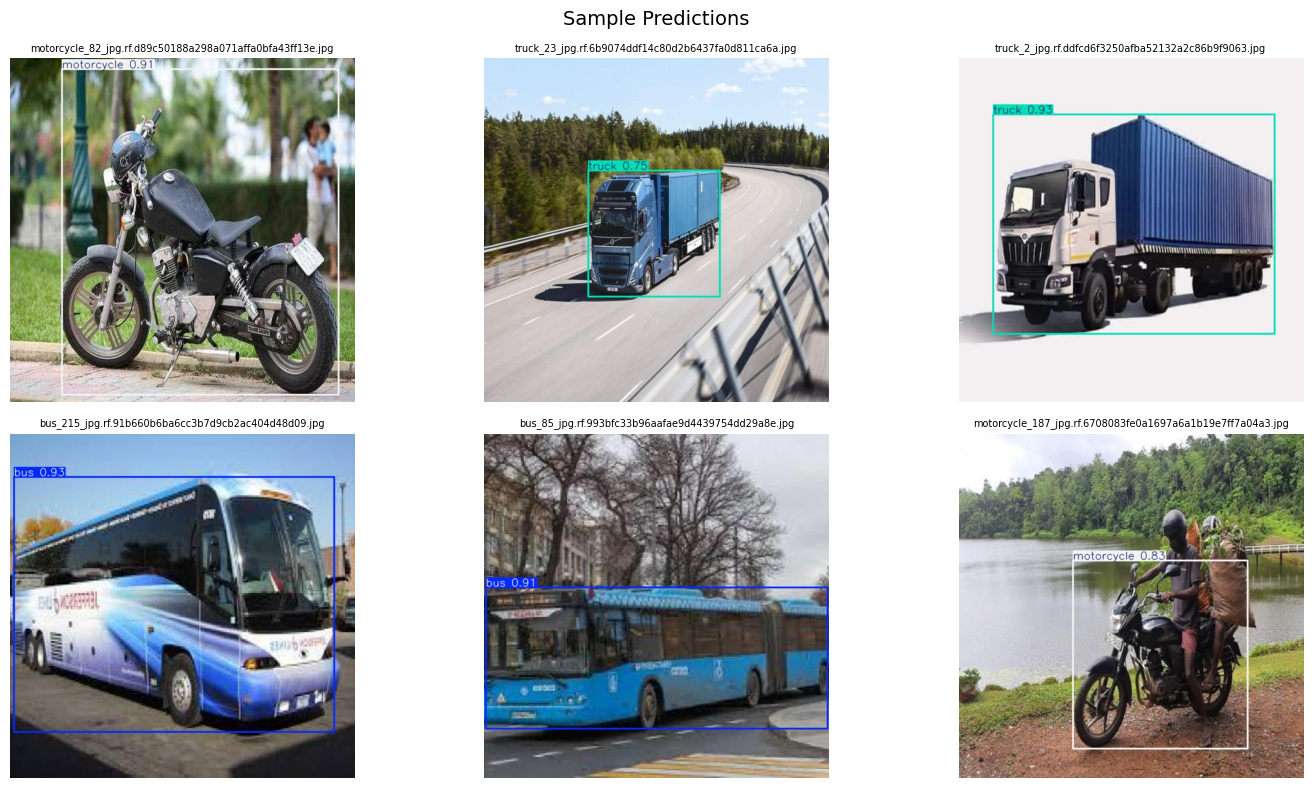

In [18]:
import random

# Pick 6 random predictions
all_pred_images = glob.glob(f'{PRED_OUTPUT}/test_predictions/*.jpg')
random.seed(44)
pred_images = random.sample(all_pred_images, min(6, len(all_pred_images)))

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Sample Predictions', fontsize=14)

for ax, img_path in zip(axes.flatten(), pred_images):
    img = plt.imread(img_path)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(os.path.basename(img_path), fontsize=7)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/vehicle_detection/vehicle-detection-project/runs/sample_predictions.png', dpi=150)
plt.show()

## Step 10: Save Model Weights Summary

In [19]:
import shutil

WEIGHTS_DIR = '/content/drive/MyDrive/vehicle_detection/vehicle-detection-project/runs/yolov8n_vehicle/weights/'

for f in ['best.pt', 'last.pt']:
    path = os.path.join(WEIGHTS_DIR, f)
    size = os.path.getsize(path) / 1024 / 1024
    print(f'{f}: {size:.1f} MB — {path}')

best.pt: 6.0 MB — /content/drive/MyDrive/vehicle_detection/vehicle-detection-project/runs/yolov8n_vehicle/weights/best.pt
last.pt: 6.0 MB — /content/drive/MyDrive/vehicle_detection/vehicle-detection-project/runs/yolov8n_vehicle/weights/last.pt
